# Notebook 7 — Correlation & Regression: Inference vs Prediction

*Quantitative Methods in Neuroscience, Master in Neuroscience, University of Geneva (2026-27)*

This is the practical companion to **Lecture 7 — Correlation & Regression**. The lecture covered Pearson vs. Spearman correlation, the linear regression model (least squares, residuals, assumptions), cases where linear regression fails on low-dimensional data (e.g. circular relationships), polynomial terms and interactions, and robust regression for outliers and heavy tails.

In this notebook we put those ideas into practice on a behavioural dataset, and along the way we build up the coding skills that go with them: scatter plots, correlation functions, `statsmodels` regression and design matrices, polynomial fits, train/test splits, and residual diagnostics.

> **A note on the dataset.** For this draft we use a **synthetic** dataset built to have the right statistical properties (linear trend with noise and outliers, a sigmoidal relationship, and a circular variable). The final version of this notebook will load real behavioural data (e.g. from the [IBL](https://www.internationalbrainlab.com/) task) with `pd.read_csv(...)` instead of Section 2's simulation cell — everything downstream is written to work unchanged once that swap is made.

### By the end of this notebook you will be able to
- Build scatter plots to inspect a bivariate relationship before modelling it.
- Compute and interpret **Pearson** vs. **Spearman** correlation, and know when each is appropriate.
- Fit a linear regression with `statsmodels`, understand the **design matrix**, and interpret coefficients.
- Recognise when linear regression **fails** on low-dimensional data, e.g. circular/periodic relationships.
- Add **polynomial terms** and **interactions**, and know when they help vs. overfit.
- Use a **train/test split** to distinguish *inference* (understanding a relationship) from *prediction* (generalising to new data).
- Use **residual diagnostics** (residuals vs. fitted, Q-Q plots, Cook's distance) to check regression assumptions.
- Apply **robust regression** to handle outliers and influential points.

### Table of contents
1. [The scientific context: behaviour, correlation, and regression](#section-1)
2. [Setting up the workspace and simulating the data](#section-2)
3. [Scatter plots](#section-3)
4. [Correlation: Pearson vs. Spearman](#section-4)
5. [Linear regression: model, design matrix, least squares](#section-5)
6. [Design matrices: a worked example](#section-6)
7. [Residual diagnostics](#section-7)
8. [When linear regression fails: circular relationships](#section-8)
9. [Polynomial terms and interactions](#section-9)
10. [Train/test split: inference vs. prediction](#section-10)
11. [Robust regression: outliers and influential points](#section-11)
12. [Wrap-up and discussion](#section-12)

> **How to read this notebook.** Markdown cells explain the *concept*. Code cells implement it. Look out for **`▶ Task`** boxes: those are short exercises where you have to edit or extend the code — the scaffolding is already there, you fill in the missing lines. If you get stuck, ask the TAs. If you use AI help, treat it as a tutor, not as a replacement for thinking: you should still be able to read each line of code and explain what it does. Our custom GPT bot tuned for this course is here: https://chatgpt.com/g/g-69fc9bfc9a748191a912a124800d9254-qmn-teaching-assistant-bot


<a id="section-1"></a>
## 1. The scientific context: behaviour, correlation, and regression

A huge amount of behavioural neuroscience comes down to asking: *does variable X relate to variable Y, and can I describe that relationship with a model?* Two example questions from a typical psychophysics session (such as in  [Plainis & Murray, 2000](https://doi.org/10.1016/S0028-3932(00)00100-7)), where a participant is request to respond upon presentation of a stimulus with variable contrast (i.e. visual vividness) could be:

- Does **reaction time** get shorter as **stimulus contrast** increases, and how strong is that relationship?
- Can I **predict** a subject's choice accuracy from the contrast of the stimulus they just saw?

The first question is mostly about *inference*: we are looking for a number (a correlation, a slope) that summarises a relationship we can interpret and report. The second is more about *prediction*: we want to define a model that generalises well to new trials. Keeping this distinction in mind will matter throughout the notebook, especially once we get to train/test splits in Section 10.

Not every relationship is linear, and not every variable behaves like an ordinary number — for instance, an **orientation** or **phase** variable wraps around (0° and 360° are the same point) itself, which breaks the assumptions of an ordinary linear fit. We will see this failure mode explicitly in Section 8.


<a id="section-2"></a>
## 2. Setting up the workspace and simulating the data

> **Before you run anything**, make sure the course conda environment (`qmn`) is activated / selected as the kernel of this notebook, as described in Notebook 1.

As usual, we start by importing the libraries we need. On top of `numpy`, `pandas`, and `matplotlib`, this week we bring in `scipy.stats` (correlation functions), `statsmodels` (regression models and design matrices), and `sklearn.model_selection` (dataset splitting into train/test).


In [1]:
# --- Import the core scientific Python stack
import numpy as np                              # for numerical computing
import pandas as pd                              # for data manipulation and analysis
import matplotlib.pyplot as plt                  # for plotting
from cycler import cycler                        # for custom colours in plots
import scipy.stats as stats                      # correlation functions
import statsmodels.api as sm                     # regression models, design matrices
import statsmodels.formula.api as smf            # R-style formula interface
from sklearn.model_selection import train_test_split

# A little bit of style for the plots (same palette as previous notebooks)
plt.rcParams.update({
    "figure.figsize": (6, 4),
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 11,
    "axes.prop_cycle": cycler(color=[
        "#1f77b4",  # blue
        "#ff7f0e",  # orange
        "#5b2c83",  # purple
    ]),
})

np.random.seed(7)

print(f"NumPy       : {np.__version__}")
print(f"pandas      : {pd.__version__}")
print(f"matplotlib  : {plt.matplotlib.__version__}")
print(f"statsmodels : {sm.__version__}")


NumPy       : 2.3.5
pandas      : 3.0.3
matplotlib  : 3.11.0
statsmodels : 0.14.6


Now we build the dataset. We simulate `n_subjects` subjects each completing `trials_per_subject` trials of a contrast-detection task, giving us:

- `contrast`: stimulus contrast (0 to 1)
- `reaction_time`: decreases roughly linearly with contrast, plus subject-level noise and a handful of slow "lapse" trials (outliers)
- `accuracy_prob`: probability of a correct choice — a **nonlinear** (sigmoidal) function of contrast ([what is a sigmoidal function?](https://en.wikipedia.org/wiki/Sigmoid_function))
- `stim_angle` / `response_angle`: the true orientation of a stimulus (0–360°) and the subject's noisy estimate of it — a **circular** variable we will come back to in Section 8

TODO: Once the real dataset is available, this whole cell will be replaced by a single line, e.g. `df = pd.read_csv("data/psychophysics_regression.csv")` — every section below is written to work unchanged as long as the column names match.


In [2]:
# --- Simulate a synthetic psychophysics-style dataset
n_subjects = 12 # how many subjects
trials_per_subject = 60 # how many trials per subject
n = n_subjects * trials_per_subject

subject_id = np.repeat(np.arange(n_subjects), trials_per_subject) # mock subjects IDs
subject_intercept = np.repeat(np.random.normal(0, 0.05, n_subjects), trials_per_subject) # random intercept per participant

contrast = np.random.uniform(0, 1, n) # random contrast variable

# Reaction time: faster with higher contrast, plus noise and a few "lapse" outliers
rt_noise = np.random.normal(0, 0.05, n)
reaction_time = 0.9 - 0.5 * contrast + subject_intercept + rt_noise
lapse_idx = np.random.choice(n, size=int(0.03 * n), replace=False)
reaction_time[lapse_idx] += np.random.uniform(0.5, 1.5, size=len(lapse_idx))
reaction_time = np.clip(reaction_time, 0.15, None)

# Choice accuracy: sigmoidal (nonlinear) function of contrast
logit = 6 * (contrast - 0.3)
accuracy_prob = 1 / (1 + np.exp(-logit))
correct_choice = np.random.binomial(1, accuracy_prob)

# Circular variable: stimulus orientation and a noisy response estimate
stim_angle = np.random.uniform(0, 360, n)
angle_noise = np.random.normal(0, 20, n)
response_angle = (stim_angle + angle_noise) % 360

# We wrap our dataset in a dataframe class to make it more easily manageable
df = pd.DataFrame({
    "subject_id": subject_id,
    "contrast": contrast,
    "reaction_time": reaction_time,
    "accuracy_prob": accuracy_prob,
    "correct_choice": correct_choice,
    "stim_angle": stim_angle,
    "response_angle": response_angle,
})

print(f"Shape (rows, columns): {df.shape}")
df.head(10) # we print the first 10 rows to check what came out


Shape (rows, columns): (720, 7)


,subject_id,contrast,reaction_time,accuracy_prob,correct_choice,stim_angle,response_angle
0,0,0.288146,0.831263,0.482226,0,274.110459,249.271504
1,0,0.909594,0.459062,0.974853,1,350.126028,13.883914
2,0,0.213385,1.003374,0.372925,1,251.859311,256.214844
3,0,0.452124,0.782220,0.713561,1,237.023820,254.192212
4,0,0.931206,0.563654,0.977844,1,122.297968,122.396647
5,0,0.024899,1.004978,0.161027,0,273.426279,276.414925
6,0,0.600549,0.730914,0.858549,1,178.964512,184.978628
7,0,0.950130,0.539866,0.980175,1,147.897159,152.471016
8,0,0.230303,0.852615,0.396952,0,228.474183,235.881492
9,0,0.548490,0.747482,0.816219,1,151.986003,150.842811


<a id="section-3"></a>
## 3. Scatter plots

Before fitting any model, it is always a good idea to actually **look at the data**. A scatter plot reveals the shape of a relationship (linear? curved? circular? unknown?), the spread of the noise, and any obvious outliers — all things that a correlation coefficient alone can hide. Also, it will let you know before doing any complicated analysis scripts, whether your data are looking reasonable :D


> **▶ Task 3.1 — Reaction time vs. contrast:**
> The code below produces a scatter plot of `reaction_time` (y-axis) against `contrast` (x-axis), it labels both axes and gives the plot a title. 
> Does the relationship look roughly linear? Do you see anything that looks like an outlier?


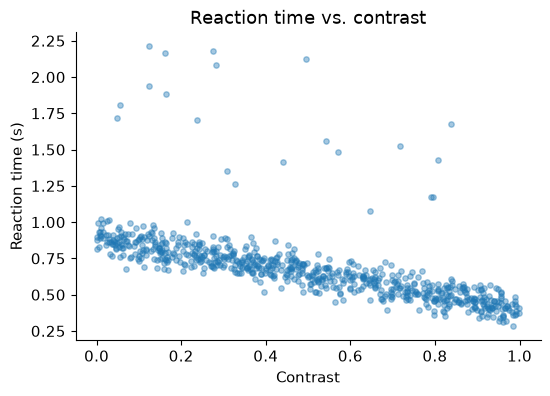

In [3]:
# TODO 3.1 — Execute the code and answer the dilemma
fig, ax = plt.subplots()
ax.scatter(df["contrast"], df["reaction_time"], alpha=0.4, s=15)   
ax.set_xlabel("Contrast")                                          
ax.set_ylabel("Reaction time (s)")                                  
ax.set_title("Reaction time vs. contrast")                          
plt.show()


**▶ Task 3.1 — Response: (Write your response in this Markdown cell)**

> **▶ Task 3.2 — Stimulus vs. response angle.**
> Make the same kind of scatter plot for `stim_angle` (x-axis) against `response_angle` (y-axis). 
> What looks different about this relationship compared to Task 3.1, especially near the edges of the axis range (close to 0° and close to 360°)?


In [4]:
# TODO 3.2 — write your code here

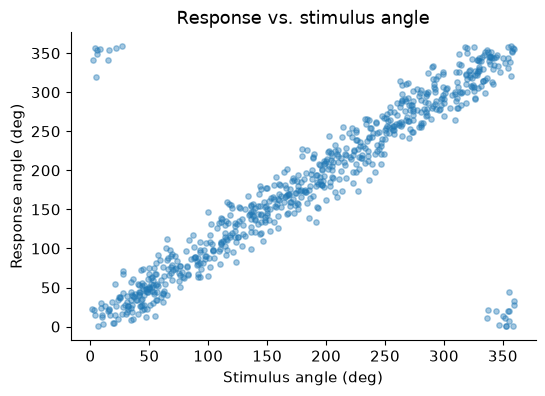

In [5]:
# Solution 3.2 
fig, ax = plt.subplots()
ax.scatter(df["stim_angle"], df["response_angle"], alpha=0.4, s=15)   
ax.set_xlabel("Stimulus angle (deg)")                                  
ax.set_ylabel("Response angle (deg)")                                  
ax.set_title("Response vs. stimulus angle")                            
plt.show()
# Note the wrap-around: points near 0 and 360 are geometrically close together,
# but the scatter plot (and any linear model) treats them as being at opposite ends.


**▶ Task 3.2 — Response: (Write your response in this Markdown cell)**

<a id="section-4"></a>
## 4. Correlation: Pearson vs. Spearman

**Pearson's r** can measure the strength of a *linear* association between two variables. **Spearman's rho** instead correlates the *ranks* of the two variables, so it captures any *monotonic* relationship (linear or not) and is more robust to outliers. When a relationship is linear-ish and outlier-free, the two will typically agree closely; when it is monotonic-but-curved, or contaminated by outliers, they can diverge.


> **▶ Task 4.1 — Correlate contrast and reaction time.**
> Using the code below, compute the Pearson and the Spearman correlation between `contrast` and `reaction_time` (`scipy.stats.pearsonr` and `scipy.stats.spearmanr`). Print both coefficients and p-values. Are the two coefficients similar? Why might that be, given what the scatter plot in Task 3.1 looked like?


In [6]:
# TODO 4.1 — Execute the code and answer the dilemma
r_pearson, p_pearson = stats.pearsonr(df["contrast"], df["reaction_time"])    
r_spearman, p_spearman = stats.spearmanr(df["contrast"], df["reaction_time"]) 

print(f"Pearson  r = {r_pearson:.3f}, p = {p_pearson:.2e}")
print(f"Spearman r = {r_spearman:.3f}, p = {p_spearman:.2e}")


Pearson  r = -0.646, p = 2.11e-86
Spearman r = -0.882, p = 2.73e-237


**▶ Task 4.1 — Response: (Write your response in this Markdown cell)**

> **▶ Task 4.2 — Correlate contrast and accuracy.**
> `accuracy_prob` is a *monotonic but nonlinear* (sigmoidal) function of `contrast`. Compute the Pearson and Spearman correlation between the two. What do you expect to happen to each coefficient given the shape of a sigmoid, and what do you actually observe?


In [7]:
# TODO 4.2 — write your code here

In [8]:
# Solution 4.2
r_pearson, p_pearson = stats.pearsonr(df["contrast"], df["accuracy_prob"])    # TO BE REMOVED
r_spearman, p_spearman = stats.spearmanr(df["contrast"], df["accuracy_prob"]) # TO BE REMOVED

print(f"Pearson  r = {r_pearson:.3f}, p = {p_pearson:.2e}")
print(f"Spearman r = {r_spearman:.3f}, p = {p_spearman:.2e}")


Pearson  r = 0.970, p = 0.00e+00
Spearman r = 1.000, p = 0.00e+00


**▶ Task 4.2 — Response: (Write your response in this Markdown cell)**
For example, because the sigmoid is monotonic (always increasing) but not linear, Spearman tends to track the strength of that monotonic trend at least as well as Pearson — which specifically measures *linear* association and can therefore slightly understate a strong-but-curved relationship.

<a id="section-5"></a>
## 5. Linear regression: model, design matrix, least squares

A simple linear regression models the outcome as $y = \beta_0 + \beta_1 x + \varepsilon$, where $\beta_0$ is the intercept, $\beta_1$ the slope, and $\varepsilon$ the residual noise. `statsmodels` estimates $\beta_0$ and $\beta_1$ by **least squares**: the values that minimise the sum of squared residuals. Internally, it builds a **design matrix** — a table with one column of 1s (for the intercept) and one column per predictor — and solves for the coefficients using that matrix.

### The least squares criterion

For each trial $i$, the model makes a prediction $\hat{y}_i = \beta_0 + \beta_1 x_i$, and the **residual** is the gap between the observed and predicted value, $e_i = y_i - \hat{y}_i$. Least squares picks the coefficients $\beta_0, \beta_1$ that minimise the **sum of squared residuals** (also called the residual sum of squares, RSS) over all $n$ trials:

$$
\text{RSS}(\beta_0, \beta_1) = \sum_{i=1}^{n} e_i^2 = \sum_{i=1}^{n} \big(y_i - \beta_0 - \beta_1 x_i\big)^2
$$

We square the residuals so that positive and negative errors don't cancel out, and so that large errors are penalised disproportionately more than small ones (a point we'll come back to in Section 11, when a few large residuals end up dominating the fit).

### Why it has a closed-form solution

$\text{RSS}(\beta_0, \beta_1)$ is a smooth, bowl-shaped (quadratic, convex) function of $\beta_0$ and $\beta_1$, so it has a single minimum, found where its partial derivatives with respect to $\beta_0$ and $\beta_1$ are both zero. Solving that pair of equations for the single-predictor case gives the familiar formulas

$$
\hat{\beta}_1 = \frac{\sum_{i=1}^{n} (x_i - \bar{x})(y_i - \bar{y})}{\sum_{i=1}^{n} (x_i - \bar{x})^2}, \qquad \hat{\beta}_0 = \bar{y} - \hat{\beta}_1 \bar{x}
$$

where $\bar{x}$ and $\bar{y}$ are the sample means of $x$ and $y$. Notice the numerator of $\hat{\beta}_1$ is (proportional to) the covariance of $x$ and $y$, and the denominator is the variance of $x$ — the least-squares slope is essentially a rescaled covariance, which is also why it's closely related to the Pearson correlation from Section 4.

### The design-matrix (matrix) form

This is exactly what `statsmodels` computes, but written more generally so it extends directly to multiple predictors, polynomial terms (Section 9), and interactions (Section 9). Stack the intercept column of 1s and the predictor(s) into the design matrix $X$ (an $n \times p$ matrix, one row per trial, one column per parameter), and stack the outcomes into a vector $\mathbf{y}$. The model is then

$$
\mathbf{y} = X\boldsymbol{\beta} + \boldsymbol{\varepsilon}
$$

and the least-squares estimate $\hat{\boldsymbol{\beta}}$ that minimises $\lVert \mathbf{y} - X\boldsymbol{\beta} \rVert^2$ (the matrix version of the RSS above) has the closed-form solution

$$
\hat{\boldsymbol{\beta}} = (X^{\top}X)^{-1}X^{\top}\mathbf{y}
$$

known as the **normal equations**. `sm.OLS(y, X).fit()` solves precisely this equation (using a numerically stable method rather than literally inverting $X^{\top}X$) — so `model.params` are $\hat{\boldsymbol{\beta}}$, and `model.fittedvalues` are $X\hat{\boldsymbol{\beta}}$.

> **▶ Task 5.1 — Fit a linear model.**
> Using `sm.OLS`, fit a regression of `reaction_time` on `contrast` (remember to add an intercept column with `sm.add_constant`). Print `model.summary()`. What are the intercept and slope, and how would you describe them in one sentence each?


In [9]:
# TODO 5.1 — Execute the code and answer the dilemma
X = sm.add_constant(df["contrast"])       
y = df["reaction_time"]                   
model = sm.OLS(y, X).fit()                
print(model.summary())


                            OLS Regression Results                            
Dep. Variable:          reaction_time   R-squared:                       0.418
Model:                            OLS   Adj. R-squared:                  0.417
Method:                 Least Squares   F-statistic:                     515.2
Date:                Fri, 10 Jul 2026   Prob (F-statistic):           2.11e-86
Time:                        12:08:04   Log-Likelihood:                 205.30
No. Observations:                 720   AIC:                            -406.6
Df Residuals:                     718   BIC:                            -397.4
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.9432      0.013     70.869      0.0

**▶ Task 5.1 — Response: (Write your response in this Markdown cell)**

> **▶ Task 5.2 — Inspect the design matrix.**
> Print the first few rows of `X` (the design matrix you built above). What does `sm.add_constant` actually add, and why is it needed to estimate an intercept?


In [10]:
# TODO 5.2 — write your code here

In [11]:
# Solution 5.2
print(X.head())                                          
print("\nShape of design matrix:", model.model.exog.shape)  
# sm.add_constant() prepends a column of 1s, which lets the model estimate an
# intercept (the constant term) alongside the slope on 'contrast'.


   const  contrast
0    1.0  0.288146
1    1.0  0.909594
2    1.0  0.213385
3    1.0  0.452124
4    1.0  0.931206

Shape of design matrix: (720, 2)


**▶ Task 5.2 — Response: (Write your response in this Markdown cell)**

For reference, `statsmodels` also offers an R-style **formula** interface, which builds the same design matrix for you from a string:


In [12]:
# --- Equivalent fit using the formula API
formula_model = smf.ols("reaction_time ~ contrast", data=df).fit()
print(formula_model.params)


Intercept    0.943185
contrast    -0.526366
dtype: float64


<a id="section-6"></a>
## 6. Design matrices: a worked example (EXTRA)

Section 5 introduced the design matrix $X$ in the abstract: a column of 1s for the intercept, plus one column per predictor, so that $\hat{\mathbf{y}} = X\hat{\boldsymbol{\beta}}$. Let's make this completely concrete on a tiny toy dataset — small enough to print the whole matrix and check the arithmetic by hand — before trusting `statsmodels` to build it for us on the full dataset.


In [13]:
# --- A tiny toy dataset: 5 "trials" with a known, hand-checkable pattern
toy = pd.DataFrame({
    "contrast": [0.1, 0.3, 0.5, 0.7, 0.9],
    "reaction_time": [0.78, 0.68, 0.60, 0.52, 0.42],
})

# Build the design matrix by hand: a column of 1s, then a column per predictor
X_toy = np.column_stack([
    np.ones(len(toy)),   # intercept column
    toy["contrast"],     # one column for the "contrast" predictor
])
y_toy = toy["reaction_time"].values

print("Design matrix X_toy (intercept column | contrast column):")
print(X_toy)


Design matrix X_toy (intercept column | contrast column):
[[1.  0.1]
 [1.  0.3]
 [1.  0.5]
 [1.  0.7]
 [1.  0.9]]


Each **row** of `X_toy` is one trial; each **column** is one parameter of the model. Row $i$, dotted with the coefficient vector $\boldsymbol{\beta} = (\beta_0, \beta_1)$, gives that trial's prediction $\hat{y}_i = \beta_0 \cdot 1 + \beta_1 \cdot x_i$ — which is exactly why the intercept needs its own column of constant 1s: it's just a predictor that never changes.

Now let's solve the normal equations from Section 5, $\hat{\boldsymbol{\beta}} = (X^{\top}X)^{-1}X^{\top}\mathbf{y}$, by hand with `numpy`, and check that we get the same answer as `sm.OLS`.


In [14]:
# --- Solve the normal equations by hand, then compare to sm.OLS
beta_hand = np.linalg.inv(X_toy.T @ X_toy) @ X_toy.T @ y_toy
print("beta from normal equations (by hand):", beta_hand)

toy_model = sm.OLS(y_toy, X_toy).fit()
print("beta from sm.OLS:                    ", toy_model.params)


beta from normal equations (by hand): [ 0.82 -0.44]
beta from sm.OLS:                     [ 0.82 -0.44]


The two match (up to floating-point rounding) — `sm.OLS` is solving exactly the equation from Section 5, just with a numerically safer algorithm than a literal matrix inverse.

### Adding more columns: categorical predictors

The real power of the design-matrix view is that it scales to more than one predictor without changing the recipe at all — every extra predictor is just one more column. This includes **categorical** predictors, like `subject_id`: instead of a single numeric column, a categorical variable with $k$ levels gets turned into $k-1$ **dummy (indicator) columns** (one level is left out as the *reference level*, so the intercept represents that reference level, and each dummy coefficient represents the *offset* from it). `statsmodels`'s formula interface (`C(...)`) builds these dummy columns for us automatically — this is what was happening under the hood back in Section 5's `contrast * C(subject_id)` interaction model, and what we'll rely on again for polynomial terms in Section 9.

Let's see it explicitly on a small slice of subjects:


In [ ]:
# --- See the dummy-coded design matrix statsmodels builds for a categorical predictor
toy_subjects = pd.DataFrame({
    "contrast": [0.2, 0.6, 0.2, 0.6, 0.2, 0.6],
    "subject_id": ["S01", "S01", "S02", "S02", "S03", "S03"],
})

# patsy (statsmodels' formula engine) builds the design matrix for us
X_cat = sm.regression.linear_model.OLS.from_formula(
    "reaction_time ~ contrast + C(subject_id)",
    data=toy_subjects.assign(reaction_time=0)  # placeholder outcome, we only want to inspect X
).exog
X_cat_named = pd.DataFrame(X_cat, columns=sm.regression.linear_model.OLS.from_formula(
    "reaction_time ~ contrast + C(subject_id)",
    data=toy_subjects.assign(reaction_time=0)
).exog_names)

print(X_cat_named)


   Intercept  C(subject_id)[T.S02]  C(subject_id)[T.S03]  contrast
0        1.0                   0.0                   0.0       0.2
1        1.0                   0.0                   0.0       0.6
2        1.0                   1.0                   0.0       0.2
3        1.0                   1.0                   0.0       0.6
4        1.0                   0.0                   1.0       0.2
5        1.0                   0.0                   1.0       0.6


Notice `subject_id = "S01"` gets **no** dummy column of its own: it *is* the reference level, absorbed into the intercept. The columns `C(subject_id)[T.S02]` and `C(subject_id)[T.S03]` are 1 exactly on the rows for that subject and 0 otherwise — each coefficient on those columns is the *difference* in intercept between that subject and S01.

**Reflection.** Whether it's a single numeric predictor, several numeric predictors, dummy-coded categorical levels, polynomial terms, or interactions, the design matrix treats them all the same way: as columns to be multiplied by coefficients and added together. Sections 9 and 10 build on this directly — a polynomial term or an interaction is nothing more than another column computed from the existing predictors before the same least-squares machinery is applied.


<a id="section-7"></a>
## 7. Residual diagnostics

A linear regression comes with assumptions: residuals should have roughly constant variance (homoscedasticity), be approximately normally distributed, and be uncorrelated with the fitted values. Two quick diagnostic plots let us check this by eye: **residuals vs. fitted values**, and a **Q-Q plot** of the residuals.


> **▶ Task 7.1 — Residuals vs. fitted values.**
> Using the model from Task 5.1, plot `model.resid` against `model.fittedvalues`, with a horizontal reference line at 0. What pattern would indicate a problem with the constant-variance assumption?


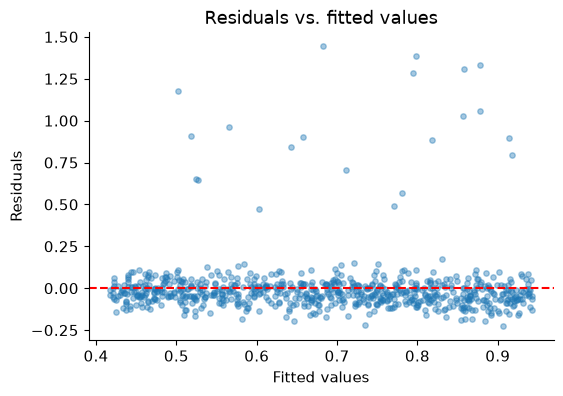

In [16]:
# TODO 7.1 — Execute the code and answer the dilemma
fig, ax = plt.subplots()
ax.scatter(model.fittedvalues, model.resid, alpha=0.4, s=15)   
ax.axhline(0, color="red", linestyle="--")                      
ax.set_xlabel("Fitted values")                                  
ax.set_ylabel("Residuals")                                       
ax.set_title("Residuals vs. fitted values")                      
plt.show()


**▶ Task 7.1 — Response: (Write your response in this Markdown cell)**

> **▶ Task 7.2 — Q-Q plot of residuals.**
> Use `sm.qqplot(model.resid, line="45", fit=True)` to check whether the residuals look approximately normal. Do the "lapse" outlier trials we injected in Section 2 show up here, and if so, how?


In [17]:
# TODO 7.2 — write your code here

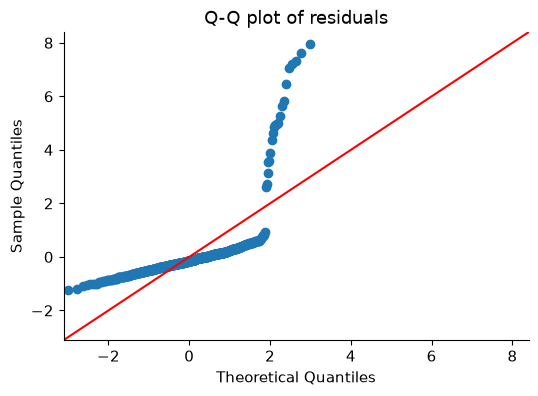

In [18]:
# 7.2 solution
sm.qqplot(model.resid, line="45", fit=True)   
plt.title("Q-Q plot of residuals")            
plt.show()
# The lapse trials show up as a cluster of large positive residuals that deviate
# from the 45-degree line in the upper tail -- a sign of heavier-than-normal tails.


**▶ Task 7.2 — Response: (Write your response in this Markdown cell)**

**Reflection.** Beyond these two plots, it's also worth checking for influential points (Cook's distance — we'll do this in Section 11) and for correlation between residuals from the same subject, which a plain OLS model ignores.


<a id="section-8"></a>
## 8. When linear regression fails: circular relationships

Recall the `stim_angle` vs. `response_angle` scatter plot from Task 3.2 — angles wrap around at 360°, so 359° and 1° are actually close together, but an ordinary linear model has no notion of that.


> **▶ Task 8.1 — Fit a (bad) linear model to circular data.**
> Fit `sm.OLS` of `response_angle` on `stim_angle`. Overlay the fitted line on the scatter plot from Task 3.2. Where does the fit look reasonable, and where does it clearly fail? Why?


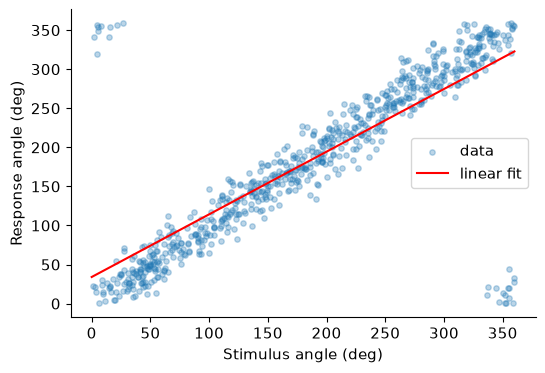

In [19]:
# TODO 8.1 — Execute the code and answer the dilemma
X_angle = sm.add_constant(df["stim_angle"])         
angle_model = sm.OLS(df["response_angle"], X_angle).fit()   

fig, ax = plt.subplots()
ax.scatter(df["stim_angle"], df["response_angle"], alpha=0.3, s=15, label="data")
xs = np.linspace(0, 360, 200)
ax.plot(xs, angle_model.params["const"] + angle_model.params["stim_angle"] * xs,   
        color="red", label="linear fit")
ax.set_xlabel("Stimulus angle (deg)")
ax.set_ylabel("Response angle (deg)")
ax.legend()
plt.show()
# Near 0/360 the wrap-around means points that are geometrically close (e.g. 5 deg
# and 355 deg) get treated by the model as being at opposite ends of the scale --
# the fit systematically breaks down near the boundary of the range.


**▶ Task 8.1 — Response: (Write your response in this Markdown cell)**

> **▶ Task 8.2 (optional / advanced) — Work in sine/cosine space.**
> Convert `stim_angle` and `response_angle` to `sin`/`cos` components (`np.sin(np.deg2rad(...))`, `np.cos(np.deg2rad(...))`), then fit two linear models predicting `resp_sin` and `resp_cos` from `stim_sin` and `stim_cos`. Why does this representation respect the circular geometry better than fitting on raw degrees?


In [20]:
# TODO 8.2 (optional) — your code here

In [21]:
# 8.2 solution
df["stim_sin"] = np.sin(np.deg2rad(df["stim_angle"]))      
df["stim_cos"] = np.cos(np.deg2rad(df["stim_angle"]))      
df["resp_sin"] = np.sin(np.deg2rad(df["response_angle"]))  
df["resp_cos"] = np.cos(np.deg2rad(df["response_angle"]))  

circ_model_sin = smf.ols("resp_sin ~ stim_sin + stim_cos", data=df).fit()   
circ_model_cos = smf.ols("resp_cos ~ stim_sin + stim_cos", data=df).fit()   
print("Sin transformed model")
print(circ_model_sin.params)
print("Cos transformed model")
print(circ_model_cos.params)
# A prediction of (sin, cos) can be converted back to an angle with arctan2, and
# there is no artificial discontinuity at 0/360 degrees -- the geometry is respected.


Sin transformed model
Intercept    0.001263
stim_sin     0.941376
stim_cos    -0.002871
dtype: float64
Cos transformed model
Intercept    0.003932
stim_sin    -0.012724
stim_cos     0.954264
dtype: float64


**▶ Task 8.2 — Response: (Write your response in this Markdown cell)**

<a id="section-9"></a>
## 9. Polynomial terms and interactions

Adding polynomial terms (e.g. `contrast**2`) lets a linear model capture curvature; adding **interaction** terms (e.g. `contrast * subject`) lets the slope of one predictor depend on the level of another. Both are powerful, and both can overfit if used carelessly — more terms will (mechanically) improve the fit to the data you have, without necessarily reflecting the true underlying process. As such, they would be very poor at generalizing..


> **▶ Task 9.1 — Linear vs. quadratic fit.**
> `accuracy_prob` is a sigmoidal function of `contrast`. Fit a linear model (`accuracy_prob ~ contrast`) and a quadratic model (`accuracy_prob ~ contrast + I(contrast**2)`), and plot both fitted curves over the scatter of the data. Compare their $R^2$. Does the quadratic term help? Would a higher-order polynomial help more, or would it just be fitting noise?


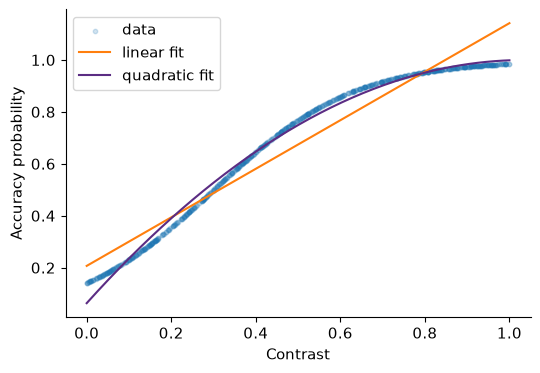

Linear R-squared:    0.940026581897759
Quadratic R-squared: 0.9934714912006385
Difference between the two fits: 0.053444909302879484


In [22]:
# TODO 9.1 — Execute the code and answer the dilemma
linear_fit = smf.ols("accuracy_prob ~ contrast", data=df).fit()                      
quad_fit = smf.ols("accuracy_prob ~ contrast + I(contrast**2)", data=df).fit()        

xs = np.linspace(0, 1, 200)
pred_linear = linear_fit.predict(pd.DataFrame({"contrast": xs}))
pred_quad = quad_fit.predict(pd.DataFrame({"contrast": xs}))

fig, ax = plt.subplots()
ax.scatter(df["contrast"], df["accuracy_prob"], alpha=0.2, s=10, label="data")
ax.plot(xs, pred_linear, color="C1", label="linear fit")
ax.plot(xs, pred_quad, color="C2", label="quadratic fit")
ax.set_xlabel("Contrast")
ax.set_ylabel("Accuracy probability")
ax.legend()
plt.show()

print("Linear R-squared:   ", linear_fit.rsquared)     
print("Quadratic R-squared:", quad_fit.rsquared)       
print("Difference between the two fits:", quad_fit.rsquared - linear_fit.rsquared)
# The quadratic term captures some curvature the linear model misses, but neither
# captures the true sigmoidal saturation at the extremes -- polynomials approximate
# curvature locally but extrapolate poorly, and higher-order terms raise R-squared
# somewhat mechanically without necessarily reflecting the true data-generating process.


**▶ Task 9.1 — Response: (Write your response in this Markdown cell)**

> **▶ Task 9.2 — An interaction with subject.**
> Fit `reaction_time ~ contrast * C(subject_id)` and print the first 10 estimated coefficients. What does one of the interaction coefficients tell you? With 12 subjects, how many extra parameters does this interaction add, and why should you be cautious about adding many interaction terms as the number of conditions grows?


In [23]:
# TODO 9.2 — your code here

In [24]:
# solution 9.2
interaction_fit = smf.ols("reaction_time ~ contrast * C(subject_id)", data=df).fit()   
print(interaction_fit.params.head(10))
# Each interaction coefficient represents how much that subject's contrast-slope
# differs from the reference subject's slope. With 12 subjects we already add 12
# extra parameters; with many more subjects/conditions, interactions multiply
# quickly, using up degrees of freedom and making the model harder to interpret and
# prone to overfitting. A mixed-effects model is often a better tool for subject-level
# variability than manually adding interaction terms. This you will see in the next week, stay tuned!


Intercept             1.009395
C(subject_id)[T.1]   -0.091897
C(subject_id)[T.2]   -0.030290
C(subject_id)[T.3]   -0.052821
C(subject_id)[T.4]   -0.107814
C(subject_id)[T.5]   -0.094293
C(subject_id)[T.6]   -0.013120
C(subject_id)[T.7]   -0.112632
C(subject_id)[T.8]   -0.047383
C(subject_id)[T.9]    0.042375
dtype: float64


**▶ Task 9.2 — Response: (Write your response in this Markdown cell)**

<a id="section-10"></a>
## 10. Train/test split: inference vs. prediction

So far every model has been fit on the whole dataset and interpreted through its coefficients — that's *inference*. If the goal is instead *prediction* (generalising to new trials), we need to check performance on data the model hasn't seen.


> **▶ Task 10.1 — A basic train/test split.**
> Split `df` into an 80% train set and a 20% test set with `train_test_split`. Fit `reaction_time ~ contrast` on the training set only, then compute $R^2$ on both the train and the test set (a helper `r_squared` function is provided below). Are the two values similar? Explain why.


In [25]:
def r_squared(fit, data, target):
    '''Helper function to calculate the R-squared'''
    preds = fit.predict(data)
    ss_res = np.sum((data[target] - preds) ** 2)
    ss_tot = np.sum((data[target] - data[target].mean()) ** 2)
    return 1 - ss_res / ss_tot

# TODO 10.1 — Execute the code and answer the dilemma
train_df, test_df = train_test_split(df, test_size=0.2, random_state=7)   
train_fit = smf.ols("reaction_time ~ contrast", data=train_df).fit()      

print("Train R-squared:", r_squared(train_fit, train_df, "reaction_time"))   
print("Test  R-squared:", r_squared(train_fit, test_df, "reaction_time"))    
# For a simple, well-specified linear model, train and test performance should be similar.


Train R-squared: 0.44017731823833517
Test  R-squared: 0.34386081342253083


**▶ Task 10.1 — Response: (Write your response in this Markdown cell)**

> **▶ Task 10.2 — Overfitting with polynomial degree.**
> For polynomial degrees 1, 2, 4, and 8, fit `reaction_time` as a polynomial in `contrast` on `train_df`, and print the train and test $R^2$ for each. What happens to each as the degree increases, and how does that illustrate the difference between fitting for inference vs. fitting for prediction?


In [26]:
# TODO 10.2 — your code here


In [27]:
# Solution 10.2
for degree in [1, 2, 4, 8]:                                                     
    formula = "reaction_time ~ " + " + ".join(                                  
        [f"I(contrast**{d})" for d in range(1, degree + 1)]                     
    )                                                                            
    fit_d = smf.ols(formula, data=train_df).fit()                               
    train_r2 = r_squared(fit_d, train_df, "reaction_time")                      
    test_r2 = r_squared(fit_d, test_df, "reaction_time")                        
    print(f"Degree {degree}: train R2 = {train_r2:.3f}, test R2 = {test_r2:.3f}")
# As degree increases, train R-squared tends to increase (or stay flat) while test
# R-squared can plateau or even decrease -- a classic sign of overfitting.

Degree 1: train R2 = 0.440, test R2 = 0.344
Degree 2: train R2 = 0.441, test R2 = 0.343
Degree 4: train R2 = 0.441, test R2 = 0.345
Degree 8: train R2 = 0.442, test R2 = 0.339


**▶ Task 10.2 — Response: (Write your response in this Markdown cell)**

<a id="section-11"></a>
## 11. Robust regression: outliers and influential points

Recall the "lapse" trials injected into `reaction_time` back in Section 2 — a small fraction of unusually slow trials. Ordinary least squares minimises *squared* error, so a handful of extreme points can pull the fit disproportionately. **Robust regression** (e.g. M-estimation with Huber's T norm) downweights large residuals instead.


> **▶ Task 11.1 — OLS vs. robust regression.**
> Fit `sm.OLS` and `sm.RLM` (with `sm.robust.norms.HuberT()`) of `reaction_time` on `contrast`. Compare the two estimated slopes, and plot both fitted lines over the scatter of the data. Which line is pulled more by the lapse trials?


OLS slope:  -0.5263657175406005
RLM slope:  -0.49483392026123985


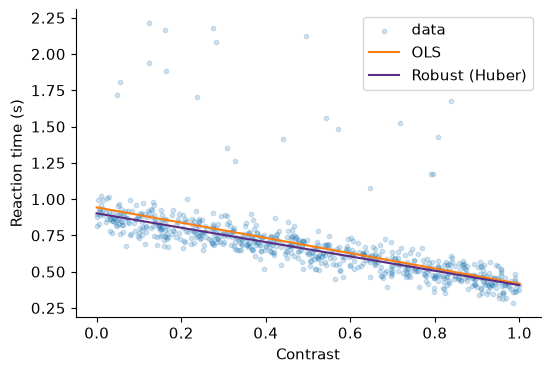

In [28]:
# TODO Execute the code and answer the dilemma
X = sm.add_constant(df["contrast"])
y = df["reaction_time"]

ols_fit = sm.OLS(y, X).fit()                                   
rlm_fit = sm.RLM(y, X, M=sm.robust.norms.HuberT()).fit()        

print("OLS slope: ", ols_fit.params["contrast"])                
print("RLM slope: ", rlm_fit.params["contrast"])                

xs = np.linspace(0, 1, 200)
Xs = sm.add_constant(xs)
fig, ax = plt.subplots()
ax.scatter(df["contrast"], df["reaction_time"], alpha=0.2, s=10, label="data")
ax.plot(xs, ols_fit.predict(Xs), color="C1", label="OLS")
ax.plot(xs, rlm_fit.predict(Xs), color="C2", label="Robust (Huber)")
ax.set_xlabel("Contrast")
ax.set_ylabel("Reaction time (s)")
ax.legend()
plt.show()
# OLS is pulled more by the handful of large-RT lapse trials, since it minimises
# squared error; the robust fit downweights those large residuals.


**▶ Task 11.1 — Response: (Write your response in this Markdown cell)**

> **▶ Task 11.2 — Cook's distance.**
> Using `ols_fit.get_influence().cooks_distance`, find the 10 most influential trials in the OLS fit. Do they overlap with the `lapse_idx` trials we injected in Section 2?


In [29]:
# TODO 11.2 — your code here


Indices of 10 most influential points: [483 290 127 129  97 451 361 331 553 557]
Overlap with injected lapse trials: 10


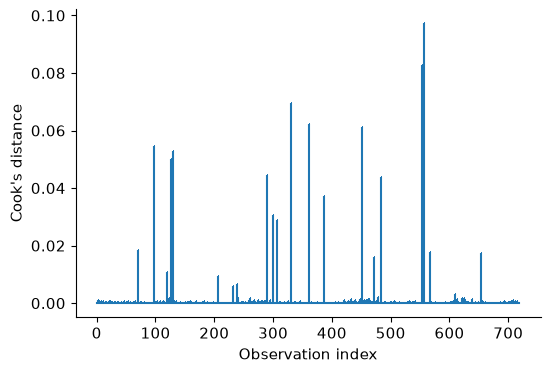

In [30]:
# Solution 11.2
influence = ols_fit.get_influence()                              
cooks_d, _ = influence.cooks_distance                             
top_influential = np.argsort(cooks_d)[-10:]                        
print("Indices of 10 most influential points:", top_influential)
print("Overlap with injected lapse trials:", len(set(top_influential) & set(lapse_idx)))   

fig, ax = plt.subplots()
ax.stem(cooks_d, markerfmt=",")
ax.set_xlabel("Observation index")
ax.set_ylabel("Cook's distance")
plt.show()
# We'd expect good overlap between the most influential points and the lapse trials
# we manually injected, confirming these outliers disproportionately affect the OLS fit.

**▶ Task 11.2 — Response: (Write your response in this Markdown cell)**

<a id="section-12"></a>
## 12. Wrap-up and discussion

1. When would you report a Pearson correlation vs. a Spearman correlation in a paper, and why?
2. What does it mean for a regression to be used for *inference* rather than *prediction*? Give one example of each from this notebook.
3. Why does a linear model struggle with circular variables like orientation or phase? What variables in your own data might have this property?
4. How do you decide how many polynomial terms are "enough" without just maximising train $R^2$?
5. What would you look for in residual diagnostics to decide whether robust regression is warranted?

**Reflection.** Every section in this notebook followed the same arc: *look at the data → summarise the relationship → fit a model → check whether the model's assumptions hold → decide whether the model is meant to explain or to predict*. That arc doesn't change as datasets grow from a few hundred simulated trials to real multi-subject behavioural datasets — only the size of the numbers involved does.

> **TA notes for the final version.** Replace the simulation cell in Section 2 with `pd.read_csv(...)`, keeping the column names (`contrast`, `reaction_time`, `correct_choice`, a circular variable such as `stim_angle`, `subject_id`) consistent with what's used throughout. Confirm the real dataset has a genuinely circular variable for Section 8 (e.g. stimulus orientation or phase); if not, adapt that section or keep it as a synthetic add-on. If `correct_choice` (binary) is used in a future week, consider a short logistic-regression bridge, since `accuracy_prob` is treated here as a continuous proxy for simplicity.


**▶ Section 12 — Response: (Write your response in this Markdown cell)**